In [39]:
from helpers import swap_order_i_j

import numpy as np
from matplotlib import pyplot as plt

In [40]:
"""
For fully symmetric interaction scheme, we need N to be 2 to the power of n
This allows each qubit to be interacted at each step, this is the best use of calculation depth
"""
N = 8

In [41]:
def interact_and_swap(i, j, order):
    """
    Simulating an interaction between two neutrinos and swapping the order
    """
    global interaction_track_matrix
    interaction_track_matrix[order[i], order[j]] += 1
    interaction_track_matrix[order[j], order[i]] += 1
    swap_order_i_j(order, i, j)
    return order

def plot_interaction_track_matrix():
    plt.imshow(interaction_track_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.show()
def interact_all(order):
    """
    Implementing interacting scheme between all neutrinos
    """
    halfN = int(N / 2) # always int when N is even
    halfNm1 = int(halfN - 1)
    for r in range(halfN): # this the the number of rounds

        # we first interact adjacent pairs

        for i in range(halfN):
            order = interact_and_swap(2*i, 2*i+1, order) 
        
        # then we interact the newly contacted pairs

        for i in range(halfNm1):
            order = interact_and_swap(2*i+1, 2*i+2, order)
        
        print("Round", r, ":", order)
        plot_interaction_track_matrix()

    return order

In [42]:
interaction_track_matrix = np.zeros((N, N), dtype=int)

order = np.arange(N)

Round 0 : [1 3 0 5 2 7 4 6]


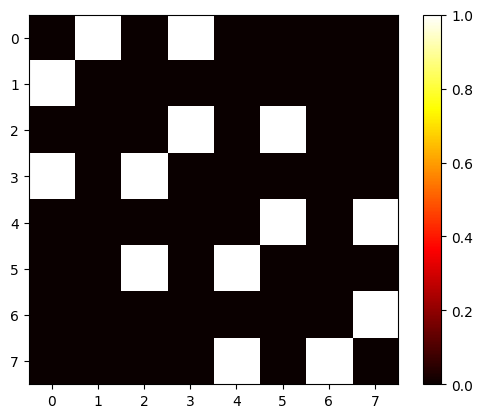

Round 1 : [3 5 1 7 0 6 2 4]


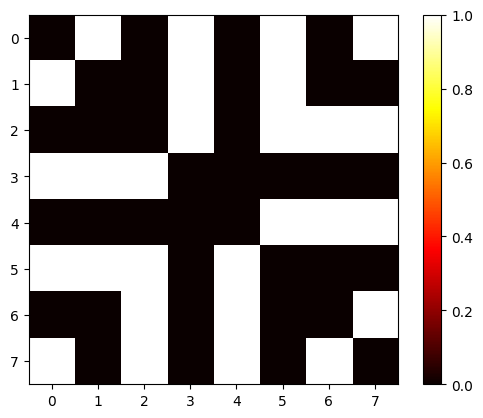

Round 2 : [5 7 3 6 1 4 0 2]


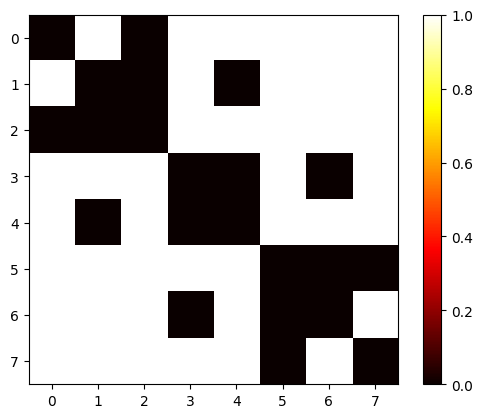

Round 3 : [7 6 5 4 3 2 1 0]


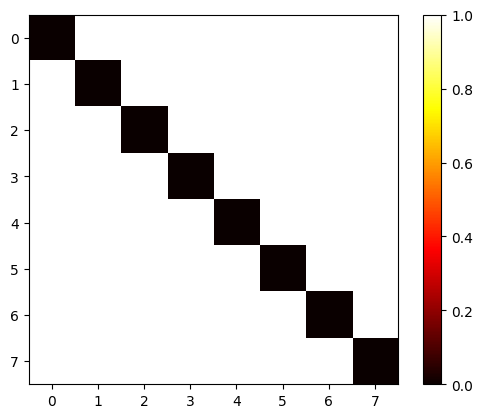

Final order of neutrinos after interaction:
[7 6 5 4 3 2 1 0]
Interaction track matrix:
[[0 1 1 1 1 1 1 1]
 [1 0 1 1 1 1 1 1]
 [1 1 0 1 1 1 1 1]
 [1 1 1 0 1 1 1 1]
 [1 1 1 1 0 1 1 1]
 [1 1 1 1 1 0 1 1]
 [1 1 1 1 1 1 0 1]
 [1 1 1 1 1 1 1 0]]


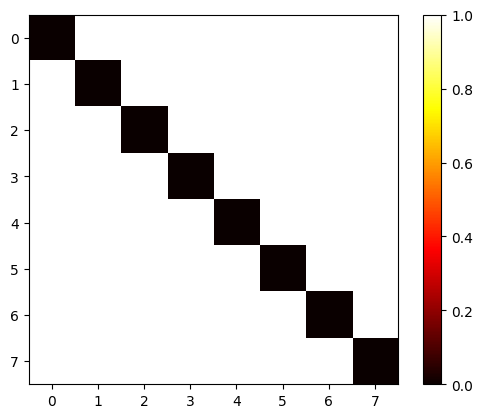

In [43]:
order = interact_all(order)
print("Final order of neutrinos after interaction:")
print(order)
print("Interaction track matrix:")
print(interaction_track_matrix)
plt.imshow(interaction_track_matrix, cmap='hot', interpolation='nearest')
plt.colorbar()